Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS

Load Clean Dataset

In [2]:
df = pd.read_csv("../data/cleaned_ecommerce.csv")

In [3]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,year,month,day,hour
0,2019-11-01 00:00:00+00:00,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33,2019,11,1,0
1,2019-11-01 00:00:00+00:00,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283,2019,11,1,0
2,2019-11-01 00:00:01+00:00,view,17302664,2053013553853497655,Unknown,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387,2019,11,1,0
3,2019-11-01 00:00:01+00:00,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f,2019,11,1,0
4,2019-11-01 00:00:01+00:00,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2,2019,11,1,0


Select Features for Dimensionality Reduction

In [4]:
features = df[['price','month','day','hour']]

In [5]:
features.head()

,price,month,day,hour
0,489.07,11,1,0
1,293.65,11,1,0
2,28.31,11,1,0
3,712.87,11,1,0
4,183.27,11,1,0


Standardize the Data

In [6]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [7]:
scaled_features[:5]

array([[ 0.6054509 ,  0.        ,  0.        , -2.07119224],
       [ 0.03480288,  0.        ,  0.        , -2.07119224],
       [-0.74001927,  0.        ,  0.        , -2.07119224],
       [ 1.25897165,  0.        ,  0.        , -2.07119224],
       [-0.28751893,  0.        ,  0.        , -2.07119224]])

Apply PCA

In [8]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_features)

In [9]:
pca_df = pd.DataFrame(data=pca_result, columns=['PC1','PC2'])

pca_df.head()

,PC1,PC2
0,1.892673,-1.036436
1,1.489163,-1.439945
2,0.941281,-1.987827
3,2.354781,-0.574327
4,1.261247,-1.667861


Visualize PCA

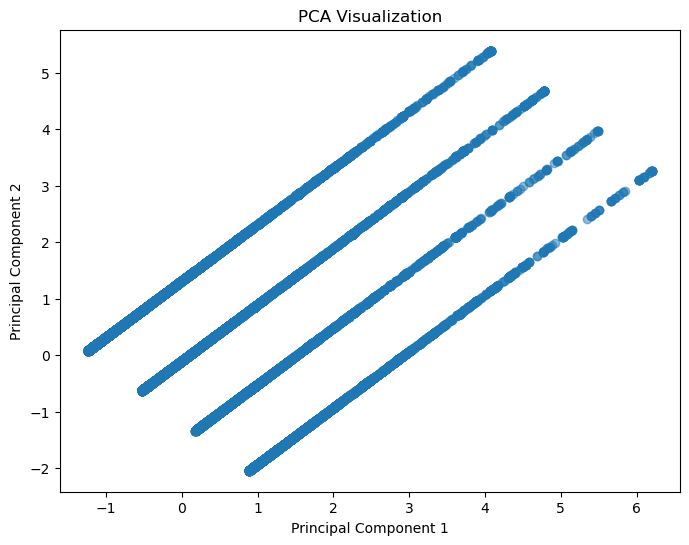

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5)
plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Explained Variance

In [11]:
pca.explained_variance_ratio_

array([0.51084041, 0.48915959])

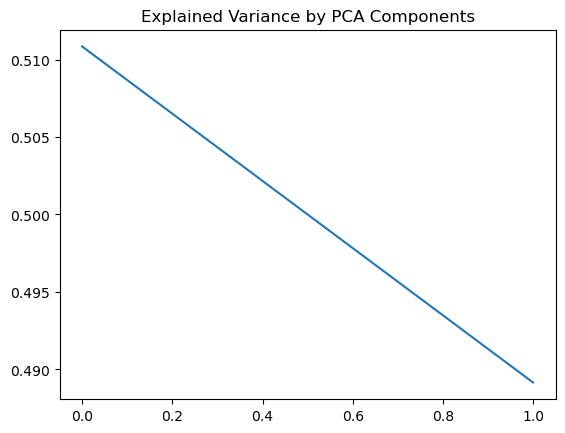

In [12]:
plt.plot(pca.explained_variance_ratio_)
plt.title("Explained Variance by PCA Components")
plt.show()

Apply Multidimensional Scaling (MDS)

In [19]:
sample_features = features.sample(n=500, random_state=42)

scaled_sample = scaler.fit_transform(sample_features)

In [20]:
mds = MDS(
    n_components=2,
    random_state=42,
    normalized_stress='auto'
)

mds_result = mds.fit_transform(scaled_sample)

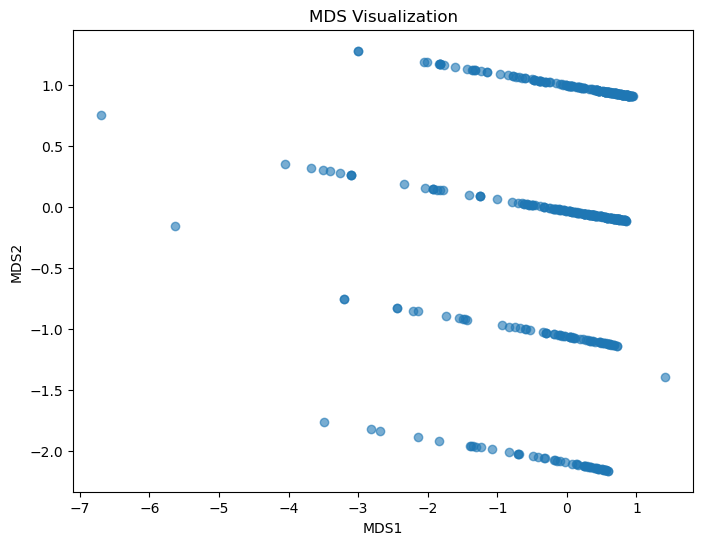

In [21]:
mds_df = pd.DataFrame(mds_result, columns=['MDS1','MDS2'])

plt.figure(figsize=(8,6))
plt.scatter(mds_df['MDS1'], mds_df['MDS2'], alpha=0.6)

plt.title("MDS Visualization")
plt.xlabel("MDS1")
plt.ylabel("MDS2")

plt.show()